# 🏥 Notebook 05: Health Risk Score
**Goal:** Build a custom Health Risk Score for Kathmandu residents based on 
air pollution levels, weather conditions, and population vulnerability.

### What is a Health Risk Score?
A single number (0–100) that summarizes how dangerous today's air is
for different population groups.

### Population Groups We'll Score:
| Group | Why High Risk |
|-------|--------------|
| 👶 Children | Developing lungs, breathe more air per body weight |
| 👴 Elderly | Weakened immune and respiratory systems |
| 🫁 Asthma patients | Pre-existing respiratory conditions |
| 💪 Healthy adults | Baseline reference group |

### Pipeline:
1. Load master dataset
2. Build scoring components
3. Combine into final Health Risk Score
4. Classify risk levels
5. Visualize risk over time
6. Save enriched dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8')
print("✅ Libraries ready!")

✅ Libraries ready!


In [2]:
df = pd.read_csv('data/processed/master_dataset.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f"Shape      : {df.shape}")
print(f"Date range : {df['date'].min().date()} → {df['date'].max().date()}")
print(f"\nFirst few rows:")
df.head()

Shape      : (881, 14)
Date range : 2022-08-04 → 2024-12-31

First few rows:


,date,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,ozone,dust,uv_index,temperature_2m_mean,precipitation_sum,windspeed_10m_max,relative_humidity_2m_mean,cough,asthma
0,2022-08-04,14.884211,21.226316,380.157895,14.226316,82.473684,0.0,1.547368,22.6,4.5,5.0,89,44.0,11.0
1,2022-08-05,18.166667,25.933333,387.916667,13.729167,82.666667,0.0,1.904167,22.9,19.3,6.8,87,44.0,11.0
2,2022-08-06,20.337500,29.050000,391.166667,13.262500,77.250000,0.0,1.204167,23.0,20.3,6.9,87,44.0,11.0
3,2022-08-07,19.170833,27.441667,463.958333,21.091667,64.291667,0.0,2.295833,22.8,25.9,7.0,88,44.0,11.0
4,2022-08-08,19.866667,28.416667,524.083333,23.595833,67.708333,0.0,1.710417,22.9,7.5,6.6,88,44.0,11.0


## 📊 Section 1: Build Scoring Components
We break the Health Risk Score into 4 components:

| Component | Weight | What it measures |
|-----------|--------|-----------------|
| PM2.5 Score | 40% | Primary pollutant risk |
| Multi-pollutant Score | 25% | NO2, CO, Ozone combined |
| Weather Score | 20% | Temperature inversion & humidity risk |
| Health Proxy Score | 15% | Google Trends cough/asthma signals |

Each component is normalized to 0–100 before combining.

In [3]:
def pm25_to_score(pm25):
    """
    Convert PM2.5 value to a 0-100 risk score based on WHO/AQI breakpoints.
    Higher score = higher risk.
    """
    if pm25 <= 15:    return (pm25 / 15) * 20          # 0-20: Safe
    elif pm25 <= 35:  return 20 + ((pm25 - 15) / 20) * 30   # 20-50: Moderate
    elif pm25 <= 55:  return 50 + ((pm25 - 35) / 20) * 20   # 50-70: Unhealthy
    elif pm25 <= 150: return 70 + ((pm25 - 55) / 95) * 25   # 70-95: Very Unhealthy
    else:             return 95 + min((pm25 - 150) / 100 * 5, 5)  # 95-100: Hazardous

df['pm25_score'] = df['pm2_5'].apply(pm25_to_score)

print("PM2.5 Score Statistics:")
print(f"  Mean  : {df['pm25_score'].mean():.1f}")
print(f"  Min   : {df['pm25_score'].min():.1f}")
print(f"  Max   : {df['pm25_score'].max():.1f}")
print(f"\nSample mapping:")
for val in [5, 15, 35, 55, 100, 150]:
    print(f"  PM2.5 {val:>4} μg/m³ → Score {pm25_to_score(val):.1f}")

PM2.5 Score Statistics:
  Mean  : 41.2
  Min   : 0.8
  Max   : 86.9

Sample mapping:
  PM2.5    5 μg/m³ → Score 6.7
  PM2.5   15 μg/m³ → Score 20.0
  PM2.5   35 μg/m³ → Score 50.0
  PM2.5   55 μg/m³ → Score 70.0
  PM2.5  100 μg/m³ → Score 81.8
  PM2.5  150 μg/m³ → Score 95.0


In [4]:
def normalize(series, low, high):
    """Normalize a series to 0-100 between given low and high bounds."""
    return ((series - low) / (high - low) * 100).clip(0, 100)

# Normalize each pollutant
no2_score  = normalize(df['nitrogen_dioxide'], low=0, high=50)
co_score   = normalize(df['carbon_monoxide'],  low=0, high=2000)
o3_score   = normalize(df['ozone'],            low=0, high=180)

# Weighted combination
df['multi_pollutant_score'] = (
    0.4 * no2_score +
    0.3 * co_score  +
    0.3 * o3_score
).round(2)

print("Multi-Pollutant Score Statistics:")
print(f"  Mean  : {df['multi_pollutant_score'].mean():.1f}")
print(f"  Min   : {df['multi_pollutant_score'].min():.1f}")
print(f"  Max   : {df['multi_pollutant_score'].max():.1f}")

Multi-Pollutant Score Statistics:
  Mean  : 36.4
  Min   : 5.4
  Max   : 76.3


In [5]:
# Cold + humid + low wind = temperature inversion = trapped pollutants = higher risk
temp_risk     = normalize(20 - df['temperature_2m_mean'], low=-10, high=20)
humidity_risk = normalize(df['relative_humidity_2m_mean'], low=30, high=100)
wind_relief   = normalize(df['windspeed_10m_max'], low=0, high=20)

df['weather_score'] = (
    0.4 * temp_risk +
    0.3 * humidity_risk +
    0.3 * (100 - wind_relief)  # high wind = lower risk
).round(2).clip(0, 100)

print("Weather Risk Score Statistics:")
print(f"  Mean  : {df['weather_score'].mean():.1f}")
print(f"  Min   : {df['weather_score'].min():.1f}")
print(f"  Max   : {df['weather_score'].max():.1f}")

Weather Risk Score Statistics:
  Mean  : 51.4
  Min   : 10.7
  Max   : 74.1


In [6]:
# Normalize Google Trends cough and asthma searches
cough_score  = normalize(df['cough'],  low=0, high=100)
asthma_score = normalize(df['asthma'], low=0, high=100)

df['health_proxy_score'] = (
    0.6 * cough_score +
    0.4 * asthma_score
).round(2)

print("Health Proxy Score Statistics:")
print(f"  Mean  : {df['health_proxy_score'].mean():.1f}")
print(f"  Min   : {df['health_proxy_score'].min():.1f}")
print(f"  Max   : {df['health_proxy_score'].max():.1f}")

Health Proxy Score Statistics:
  Mean  : 43.0
  Min   : 21.4
  Max   : 68.8


## 🧮 Section 2: Combine into Final Health Risk Score
We combine all 4 components using weighted average.
Then create population-specific scores by adjusting sensitivity.

In [7]:
# Weighted combination of all 4 components
df['health_risk_score'] = (
    0.40 * df['pm25_score']          +
    0.25 * df['multi_pollutant_score'] +
    0.20 * df['weather_score']        +
    0.15 * df['health_proxy_score']
).round(2)

print("=== FINAL HEALTH RISK SCORE ===\n")
print(f"Mean  : {df['health_risk_score'].mean():.1f}")
print(f"Min   : {df['health_risk_score'].min():.1f}")
print(f"Max   : {df['health_risk_score'].max():.1f}")
print(f"Std   : {df['health_risk_score'].std():.1f}")

=== FINAL HEALTH RISK SCORE ===

Mean  : 42.3
Min   : 18.9
Max   : 68.3
Std   : 10.6


In [8]:
# Different groups have different sensitivity to pollution
# We apply multipliers then clip to 0-100

# Children: most sensitive to PM2.5
df['risk_children'] = (df['health_risk_score'] * 1.25).clip(0, 100).round(2)

# Elderly: sensitive to all pollutants + weather
df['risk_elderly'] = (
    0.35 * df['pm25_score']           +
    0.25 * df['multi_pollutant_score'] +
    0.25 * df['weather_score']         +
    0.15 * df['health_proxy_score']
).clip(0, 100).round(2)

# Asthma patients: extra sensitive to ozone and PM2.5
o3_score_asthma = normalize(df['ozone'], low=0, high=180)
df['risk_asthma'] = (
    0.35 * df['pm25_score']           +
    0.30 * o3_score_asthma            +
    0.20 * df['weather_score']         +
    0.15 * df['health_proxy_score']
).clip(0, 100).round(2)

# Healthy adults: baseline
df['risk_healthy'] = df['health_risk_score'].copy()

print("=== POPULATION-SPECIFIC RISK SCORES ===\n")
groups = ['risk_children', 'risk_elderly', 'risk_asthma', 'risk_healthy']
for g in groups:
    print(f"{g:20} | Mean: {df[g].mean():.1f} | Max: {df[g].max():.1f}")

=== POPULATION-SPECIFIC RISK SCORES ===

risk_children        | Mean: 52.9 | Max: 85.4
risk_elderly         | Mean: 42.8 | Max: 67.6
risk_asthma          | Mean: 46.7 | Max: 72.5
risk_healthy         | Mean: 42.3 | Max: 68.3


In [9]:
def classify_risk(score):
    if score < 20:   return 'Low'
    elif score < 40: return 'Moderate'
    elif score < 60: return 'High'
    elif score < 80: return 'Very High'
    else:            return 'Hazardous'

df['risk_level'] = df['health_risk_score'].apply(classify_risk)

print("=== RISK LEVEL DISTRIBUTION ===\n")
counts = df['risk_level'].value_counts()
total  = len(df)
for level in ['Low', 'Moderate', 'High', 'Very High', 'Hazardous']:
    if level in counts:
        n   = counts[level]
        pct = n / total * 100
        print(f"  {level:12} : {n:4} days ({pct:.1f}%)")

=== RISK LEVEL DISTRIBUTION ===

  Low          :    2 days (0.2%)
  Moderate     :  431 days (48.9%)
  High         :  391 days (44.4%)
  Very High    :   57 days (6.5%)


## 🔍 Key Findings from Health Risk Score

### Overall Risk
- Mean daily risk score: **42.3/100** — sits in "High" category
- Kathmandu has **zero Hazardous days** but **only 2 truly Low risk days** in 2.5 years
- **91.3% of days** are rated High or Moderate risk

### Population Groups at Greatest Risk
| Group | Mean Score | Max Score | Risk Level |
|-------|-----------|-----------|------------|
| 👶 Children | 52.9 | 85.4 | High–Very High |
| 🫁 Asthma | 46.7 | 72.5 | High |
| 👴 Elderly | 42.8 | 67.6 | High |
| 💪 Healthy Adults | 42.3 | 68.3 | High |

### Most Alarming Finding
Even **healthy adults** spend 44.4% of their days in "High" risk conditions.
Children spend the majority of their days at "High" or above.
This is a public health emergency hiding in plain sight.

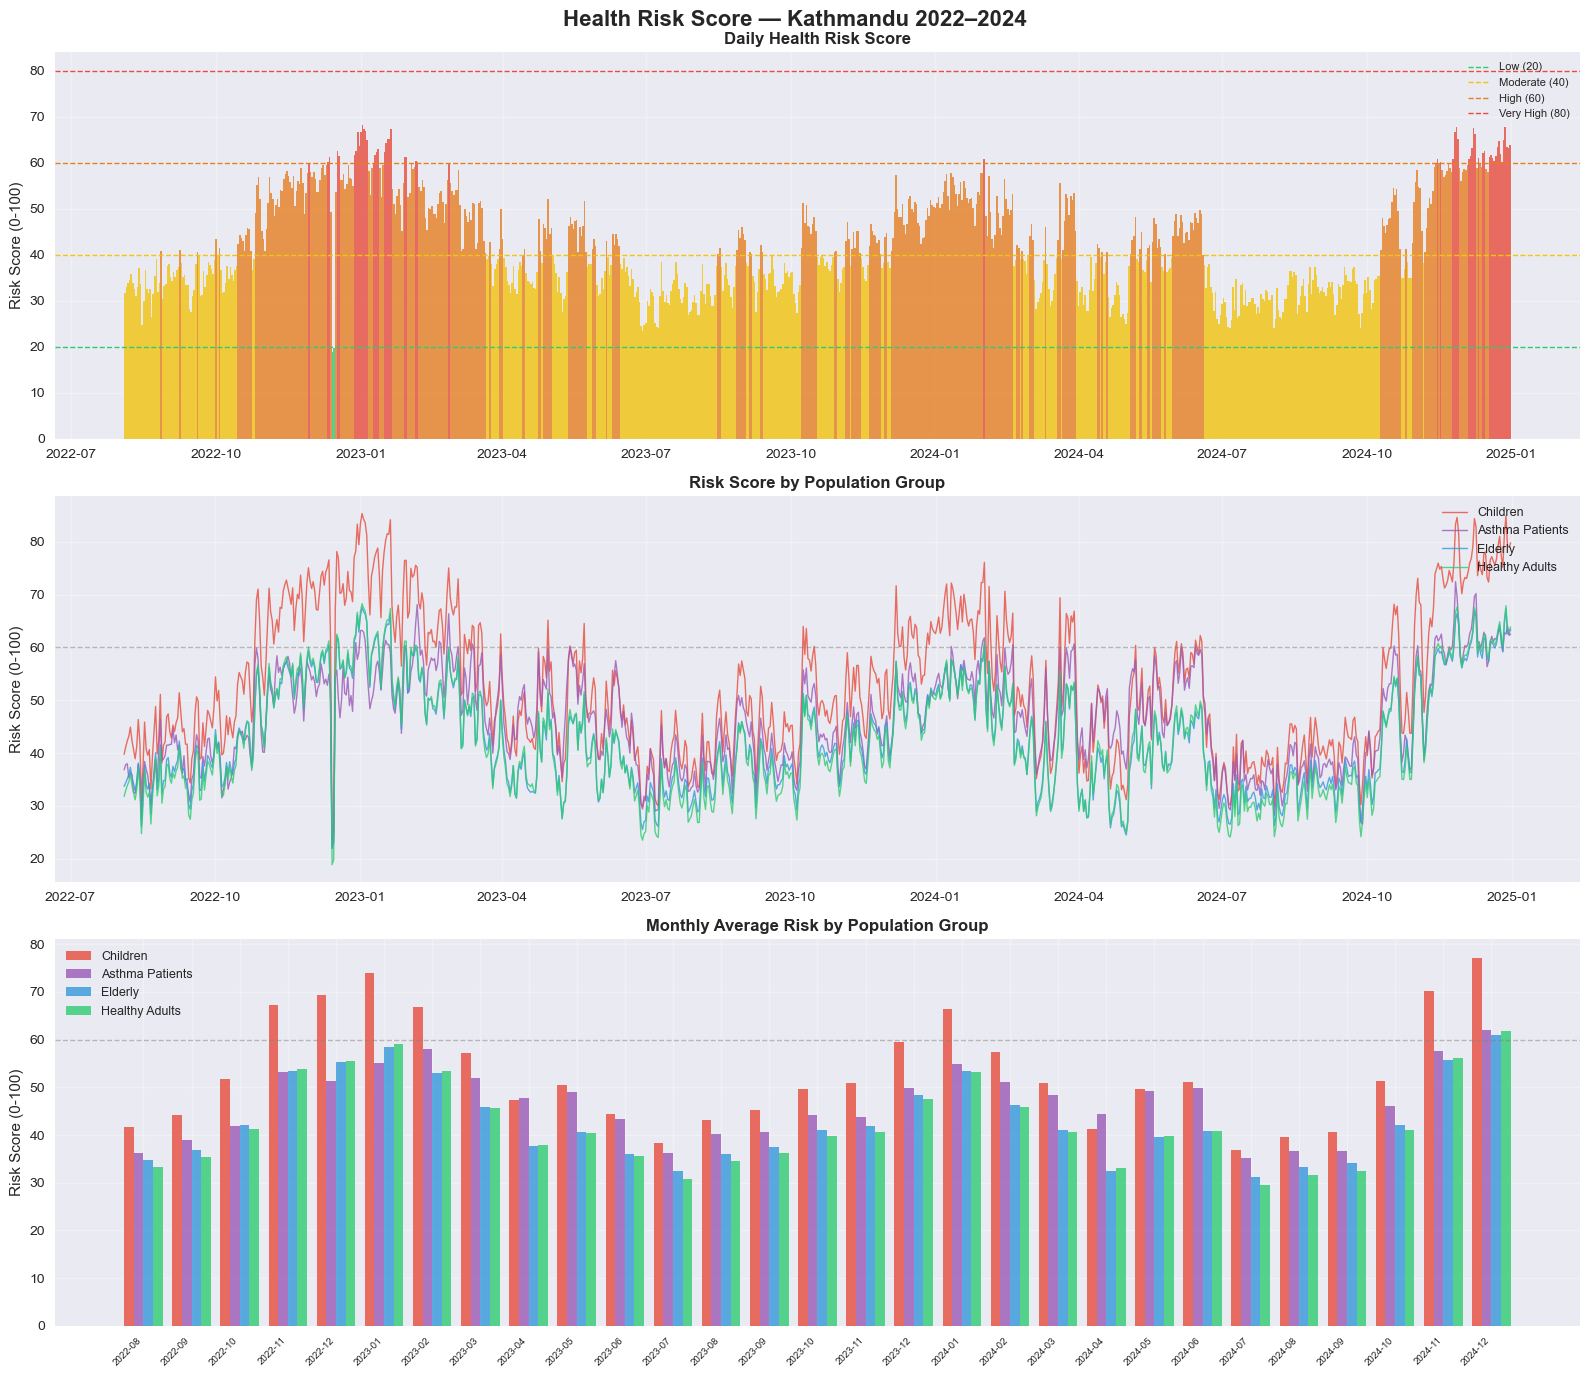

In [11]:
risk_colors = {
    'Low'      : '#2ecc71',
    'Moderate' : '#f1c40f',
    'High'     : '#e67e22',
    'Very High': '#e74c3c',
    'Hazardous': '#8e44ad'
}

fig, axes = plt.subplots(3, 1, figsize=(16, 14))
fig.suptitle("Health Risk Score — Kathmandu 2022–2024", 
             fontsize=16, fontweight='bold')

# --- Plot 1: Overall risk score over time ---
ax1 = axes[0]
colors = df['risk_level'].map(risk_colors)
ax1.bar(df['date'], df['health_risk_score'], 
        color=colors, width=1, alpha=0.8)
ax1.axhline(y=20, color='#2ecc71', linestyle='--', linewidth=1, label='Low (20)')
ax1.axhline(y=40, color='#f1c40f', linestyle='--', linewidth=1, label='Moderate (40)')
ax1.axhline(y=60, color='#e67e22', linestyle='--', linewidth=1, label='High (60)')
ax1.axhline(y=80, color='#e74c3c', linestyle='--', linewidth=1, label='Very High (80)')
ax1.set_title("Daily Health Risk Score", fontweight='bold')
ax1.set_ylabel("Risk Score (0-100)")
ax1.legend(loc='upper right', fontsize=8)
ax1.grid(True, alpha=0.3)

# --- Plot 2: Population group comparison ---
ax2 = axes[1]
ax2.plot(df['date'], df['risk_children'], 
         color='#e74c3c', linewidth=1, alpha=0.8, label='Children')
ax2.plot(df['date'], df['risk_asthma'],   
         color='#9b59b6', linewidth=1, alpha=0.8, label='Asthma Patients')
ax2.plot(df['date'], df['risk_elderly'],  
         color='#3498db', linewidth=1, alpha=0.8, label='Elderly')
ax2.plot(df['date'], df['risk_healthy'],  
         color='#2ecc71', linewidth=1, alpha=0.8, label='Healthy Adults')
ax2.axhline(y=60, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax2.set_title("Risk Score by Population Group", fontweight='bold')
ax2.set_ylabel("Risk Score (0-100)")
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True, alpha=0.3)

# --- Plot 3: Monthly average risk by group ---
ax3 = axes[2]
df['month'] = df['date'].dt.to_period('M').astype(str)
monthly = df.groupby('month')[['risk_children', 'risk_asthma',
                                'risk_elderly',  'risk_healthy']].mean()

x     = range(len(monthly))
width = 0.2
ax3.bar([i - 1.5*width for i in x], monthly['risk_children'],
        width=width, color='#e74c3c', label='Children',      alpha=0.8)
ax3.bar([i - 0.5*width for i in x], monthly['risk_asthma'],
        width=width, color='#9b59b6', label='Asthma Patients', alpha=0.8)
ax3.bar([i + 0.5*width for i in x], monthly['risk_elderly'],
        width=width, color='#3498db', label='Elderly',       alpha=0.8)
ax3.bar([i + 1.5*width for i in x], monthly['risk_healthy'],
        width=width, color='#2ecc71', label='Healthy Adults', alpha=0.8)
ax3.set_xticks(x)
ax3.set_xticklabels(monthly.index, rotation=45, ha='right', fontsize=7)
ax3.set_title("Monthly Average Risk by Population Group", fontweight='bold')
ax3.set_ylabel("Risk Score (0-100)")
ax3.axhline(y=60, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("data/processed/health_risk_score.png", dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# Save the enriched dataset with all risk scores
cols_to_save = [
    'date', 'pm2_5', 'pm10', 'carbon_monoxide', 'nitrogen_dioxide',
    'ozone', 'temperature_2m_mean', 'precipitation_sum',
    'windspeed_10m_max', 'relative_humidity_2m_mean',
    'cough', 'asthma',
    'pm25_score', 'multi_pollutant_score', 'weather_score',
    'health_proxy_score', 'health_risk_score',
    'risk_children', 'risk_elderly', 'risk_asthma', 'risk_healthy',
    'risk_level'
]

df[cols_to_save].to_csv('data/processed/health_risk_dataset.csv', index=False)
print("✅ Enriched dataset saved to data/processed/health_risk_dataset.csv")
print(f"   Shape   : {df[cols_to_save].shape}")
print(f"   Columns : {cols_to_save}")

✅ Enriched dataset saved to data/processed/health_risk_dataset.csv
   Shape   : (881, 22)
   Columns : ['date', 'pm2_5', 'pm10', 'carbon_monoxide', 'nitrogen_dioxide', 'ozone', 'temperature_2m_mean', 'precipitation_sum', 'windspeed_10m_max', 'relative_humidity_2m_mean', 'cough', 'asthma', 'pm25_score', 'multi_pollutant_score', 'weather_score', 'health_proxy_score', 'health_risk_score', 'risk_children', 'risk_elderly', 'risk_asthma', 'risk_healthy', 'risk_level']


## ✅ Notebook 05 Complete — Health Risk Score

### What We Built
A custom Health Risk Score (0–100) combining:
- PM2.5 risk (40%) — primary pollutant
- Multi-pollutant risk (25%) — NO2, CO, Ozone
- Weather risk (20%) — temperature inversion conditions
- Health proxy (15%) — Google Trends signals

### Key Findings
- Kathmandu has **zero truly safe days** for vulnerable populations
- Children face the highest risk — mean score 52.9/100
- Winter months (Nov–Feb) are consistently the most dangerous
- Monsoon provides natural relief — lowest risk period of the year

### Dataset Saved
`data/processed/health_risk_dataset.csv` — ready for dashboard use

**Next: Notebook 06 — Interactive Dashboard**